24RB1074　半田悠人

## 課題1: 12頂点のグラフの2分割を考える．グラフが接続のない $K$ 個の部分グラフからなる様に隣接⾏列 $W$ を適当に定義せよ.

In [61]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

### 1-1:  グラフラプラシアン $L$ を計算し，0固有値がちょうど $K$ 個になることを確認せよ.

In [62]:
n_points = 12
K = 4
W = np.zeros((n_points, n_points))
for i in range(n_points):
    for j in range(n_points):
        if i < 3 and j < 3:
            W[i, j] = 1
        elif i >= 3 and j >= 3 and i < 6 and j < 6:
            W[i, j] = 1
        elif i >= 6 and j >= 6 and i < 9 and j < 9:
            W[i, j] = 1
        elif i >= 9 and j >= 9 and i < 12 and j < 12:
            W[i, j] = 1

D = np.diag(np.sum(W, axis=1))
L = D - W
eigenvalues, eigenvectors = np.linalg.eig(L)
zeros = eigenvalues[eigenvalues < 1e-5].size
print("Number of zero eigenvalues:", zeros)


Number of zero eigenvalues: 4


### 1-2: ⾏列 $W$ の値が0である部分に⼩さな正のノイズを加えよ．その際 $W$ の対称性が保たれる様に注意するべきだが，それを怠った場合で， $W$ の固有値を計算して⾒よ.

In [63]:
for i in range(n_points):
    for j in range(n_points):
        if W[i, j] == 0:
            W[i, j] += np.random.uniform(0, 1.0e-5)

eigenvalues_w, eigenvectors_w = np.linalg.eigh(W)
print(eigenvalues_w)


[-1.64160867e-05 -6.81166473e-06 -5.37632375e-06 -4.41118021e-06
 -6.70752922e-07  7.78542662e-06  1.03744829e-05  1.55260601e-05
  2.99998359e+00  2.99998635e+00  2.99999103e+00  3.00003904e+00]


### 1-3: 対称性を保つように $W \leftarrow 1/2W + 1/2W^T$ で隣接行列を再定義する.グラフラプラシアンLの固有値を計算し,横軸が固有値のインデックス,縦軸が固有値の値でプロットせよ.

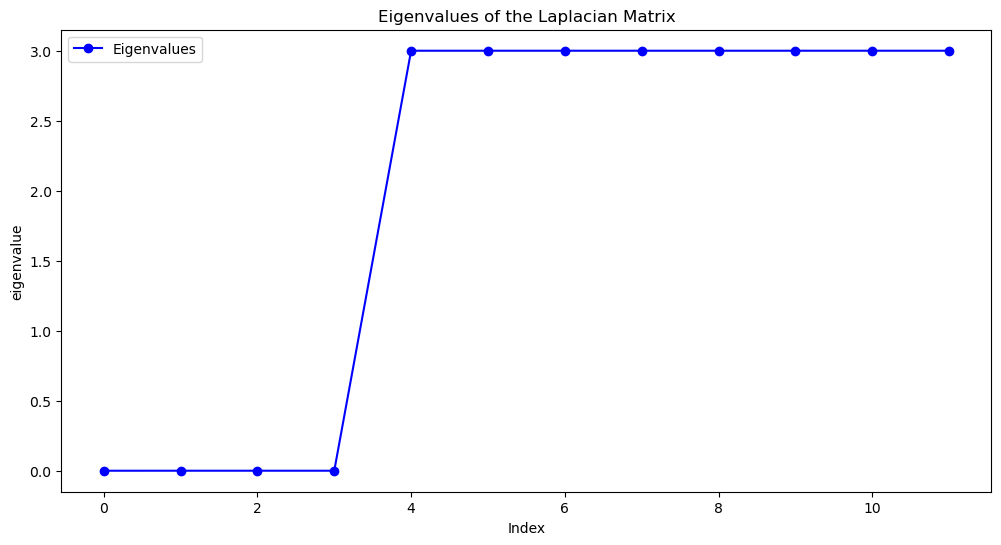

In [64]:
W = 0.5*W + 0.5*W.T
D = np.diag(np.sum(W, axis=1))
L = D - W
eigenvalues, eigenvectors = np.linalg.eigh(L)

plt.figure(figsize=(12,6))
#plt.plot(alphas, Ridge_train_MSE, label=f'{way} Train', marker='o', linestyle='--', color='red', alpha=0.7)
plt.plot(range(eigenvalues.size), eigenvalues, label='Eigenvalues', marker='o', linestyle='-', color='blue')

 # グラフの装飾
plt.xlabel('Index')
plt.ylabel('eigenvalue')
plt.title('Eigenvalues of the Laplacian Matrix')
plt.legend()

plt.show()



## 課題2：`sklearn.datasets.make_moons` (`n=200`, `noise=0.1` 程度) に対してスペクトルクラスタリングを行い、うまく分割できることを確認せよ。

Sigma: 0.01


c:\Users\hanha\miniconda3\envs\ml-exercise\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


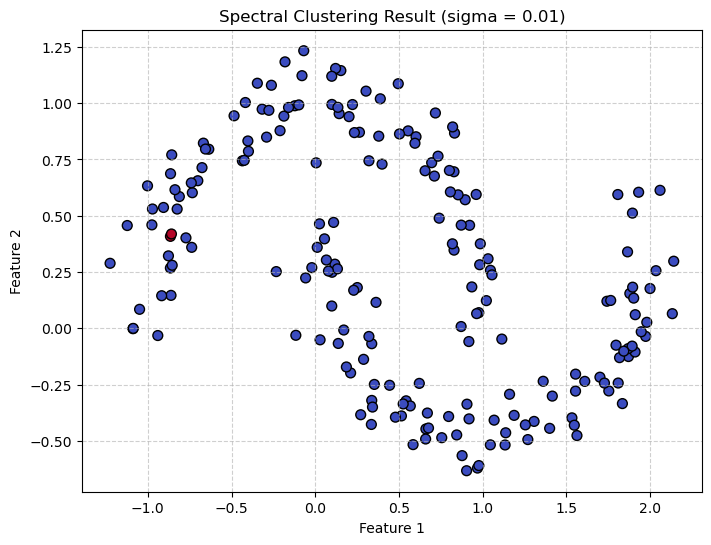

c:\Users\hanha\miniconda3\envs\ml-exercise\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


Sigma: 0.05


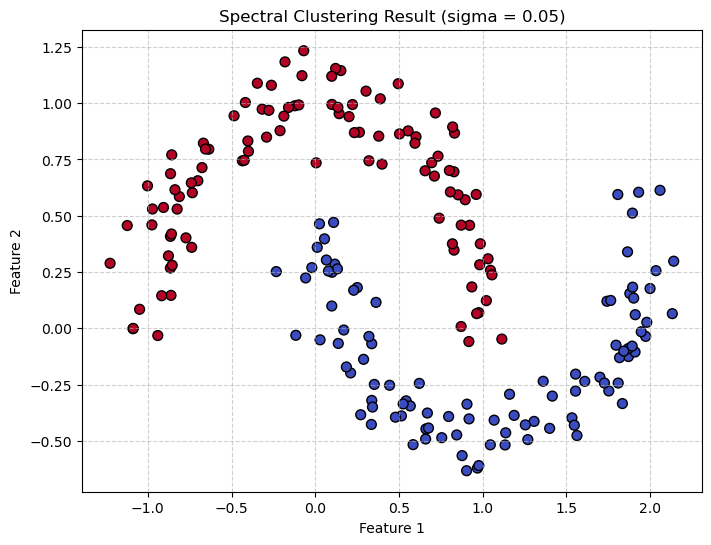

c:\Users\hanha\miniconda3\envs\ml-exercise\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


Sigma: 0.1


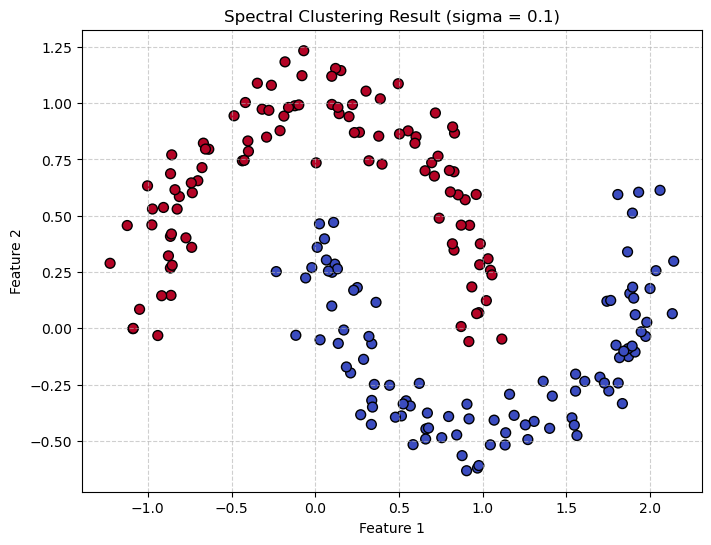

c:\Users\hanha\miniconda3\envs\ml-exercise\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


Sigma: 0.2


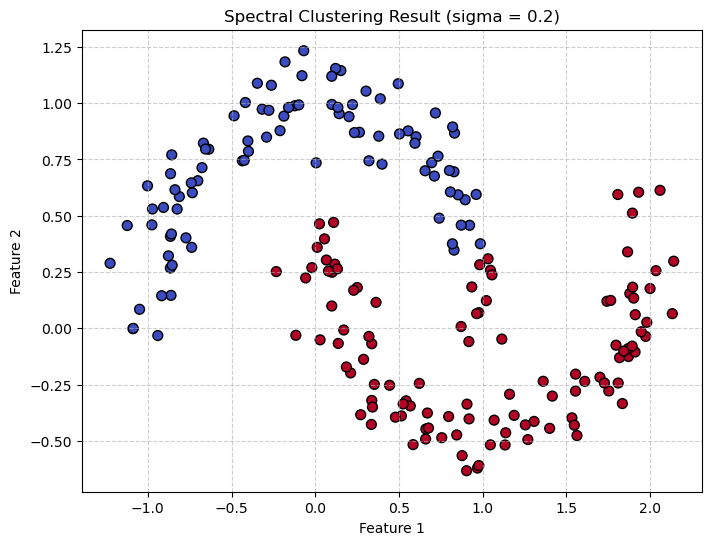

Sigma: 0.5


c:\Users\hanha\miniconda3\envs\ml-exercise\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


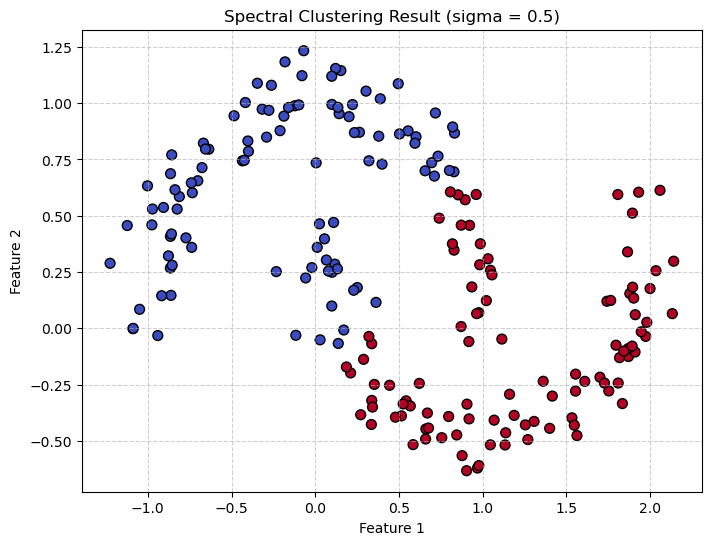

Sigma: 1.0


c:\Users\hanha\miniconda3\envs\ml-exercise\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


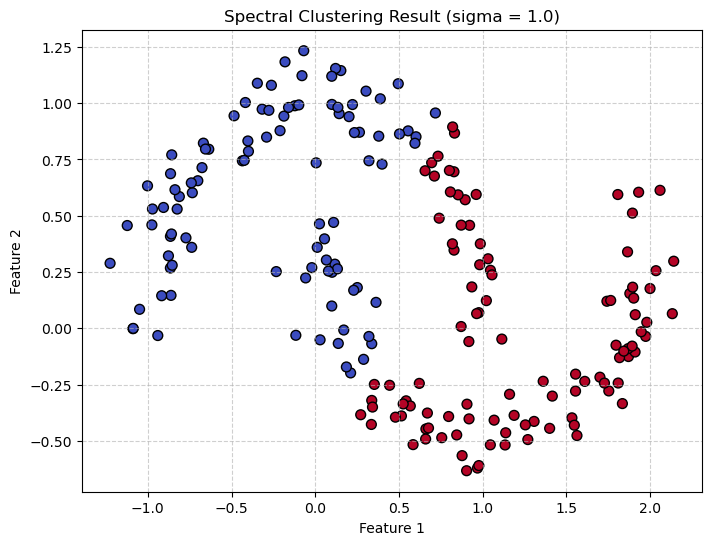

Sigma: 2.0


c:\Users\hanha\miniconda3\envs\ml-exercise\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


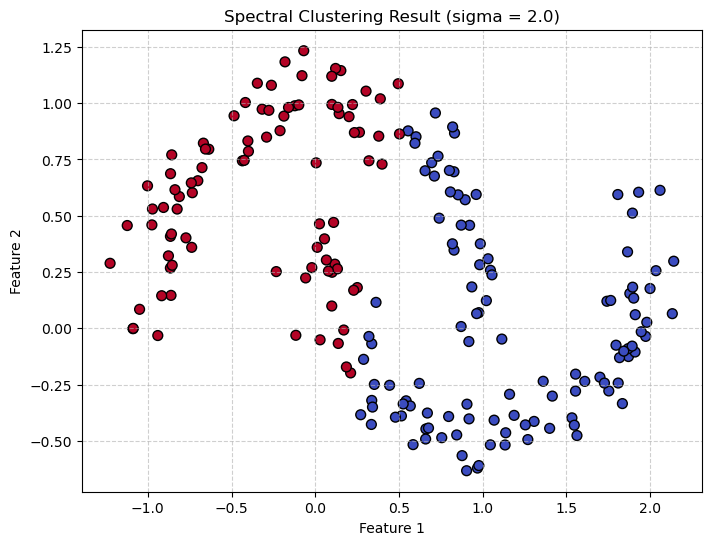

In [71]:
from sklearn.cluster import KMeans

X, y = make_moons(n_samples=200, noise=0.1, random_state=42)

K = 2

def RBF_W(X, sigma):
    n_samples = X.shape[0]
    W = np.zeros((n_samples, n_samples))
    for i in range(n_samples):
        for j in range(n_samples):
            W[i, j] = np.exp(-np.linalg.norm(X[i] - X[j])**2 / (2 * sigma**2))
    return W

sigma_values = [0.01, 0.05, 0.1, 0.2, 0.5, 1.0, 2.0]

for sigma in sigma_values:
    W = RBF_W(X, sigma=sigma)
    D = np.diag(np.sum(W, axis=1))
    L = D - W
    eigenvalues, eigenvectors = np.linalg.eigh(L)
    
    vectors = eigenvectors[:, np.argsort(eigenvalues)]
    X_embedded = vectors[:, :K]
    
    kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
    kmeans.fit(X_embedded)
    
    labels = kmeans.labels_

    print(f"Sigma: {sigma}")
    
    plt.figure(figsize=(8, 6))
    plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='coolwarm', edgecolors='k', s=50)
    plt.title(f'Spectral Clustering Result (sigma = {sigma})')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

## 観察と考察
### 課題1
* 完全に分断された $K$ 個の部分グラフを持つラプラシアン行列は、ちょうど $K$ 個の $0$ 固有値を持っていた。
* グラフから、インデックス0〜3の固有値はほぼ $0$ に張り付いており、インデックス4以降で固有値が $3.0$ へと急激に立ち上がる明確な段差が確認できた。
* この結果から、固有値が急激に大きくなる手前のインデックスを見ることで、データがいくつのクラスタに分かれるべきかを推定できる。

### 課題2
* **$\sigma = 0.01$の場合：** 1点だけが別のクラスタとして判定され、クラスタリングが崩壊している。
* **$\sigma = 0.05, 0.1$の場合：** 2つの三日月が赤と青に完璧に分離されている。
* **$\sigma = 0.5, 1.0, 2.0$の場合：** 三日月の形状を無視し、画面を上下または左右に、直線で分割したような結果となっている。

$\sigma$ が大きすぎると、異なる三日月に属する遠くの点同士まで繋がっていると誤判定してしまい、本来のグラフ構造が潰れて線形分離的な結果に陥る。逆に $\sigma$ が小さすぎると、同じ三日月内の点同士の繋がりすら切断されてしまい、孤立点が生じる。
$\sigma = 0.05 \sim 0.1$ の適切な値を設定した時のみ、K-meansでは不可能な非線形な形状のクラスタリングができた。